## 2. eda for paysim data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


In [2]:
from src.data.load import load_paysim

df = load_paysim()
print()
print(df.head())
print()
print("=== Column Info ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
print(df.isnull().sum())

正在读取 paysim.csv ...
读取完成：6,362,620 行，11 列
欺诈比例：0.129%

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

=== Column Info ===
step                int64
typ

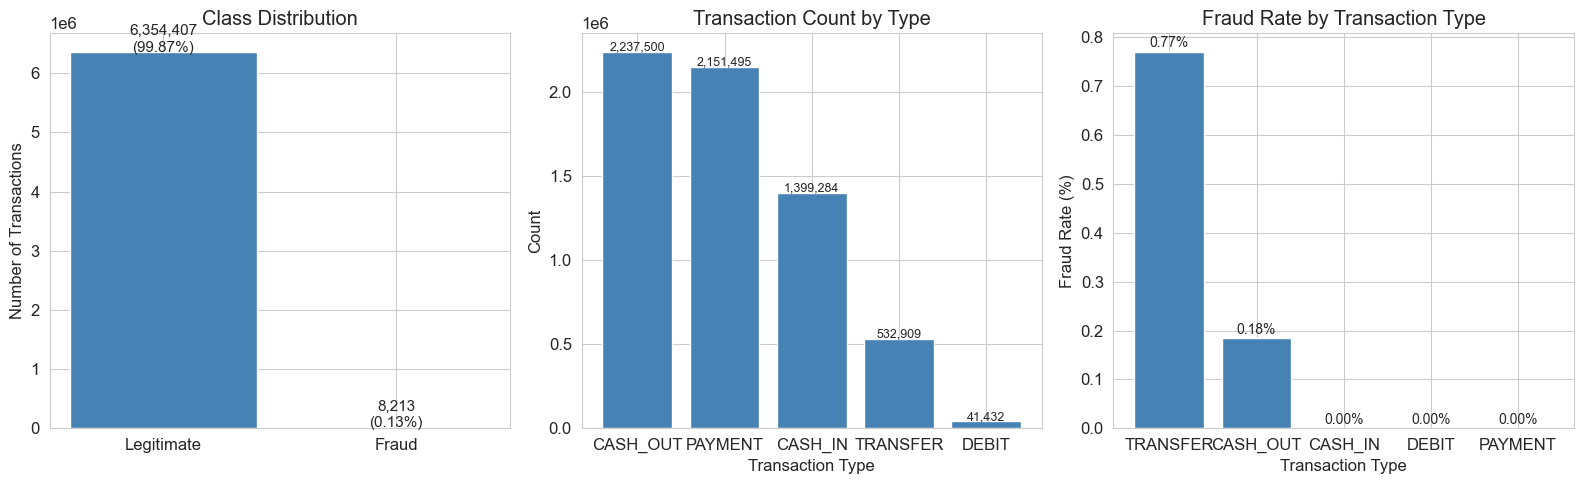

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 左图：class imbalance
fraud_counts = df['isFraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values,
            color=['steelblue', 'crimson'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 10000, f'{v:,}\n({v/len(df)*100:.2f}%)',
                 ha='center', fontsize=11)

# 中图：各交易类型数量
type_counts = df['type'].value_counts()
axes[1].bar(type_counts.index, type_counts.values,
            color='steelblue', edgecolor='white')
axes[1].set_title('Transaction Count by Type')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 10000, f'{v:,}', ha='center', fontsize=9)

# 右图：各交易类型的欺诈率
type_fraud = df.groupby('type')['isFraud'].mean() * 100
type_fraud = type_fraud.sort_values(ascending=False)
bars = axes[2].bar(type_fraud.index, type_fraud.values,
                   color='steelblue', edgecolor='white')
axes[2].set_title('Fraud Rate by Transaction Type')
axes[2].set_xlabel('Transaction Type')
axes[2].set_ylabel('Fraud Rate (%)')
for bar, val in zip(bars, type_fraud.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

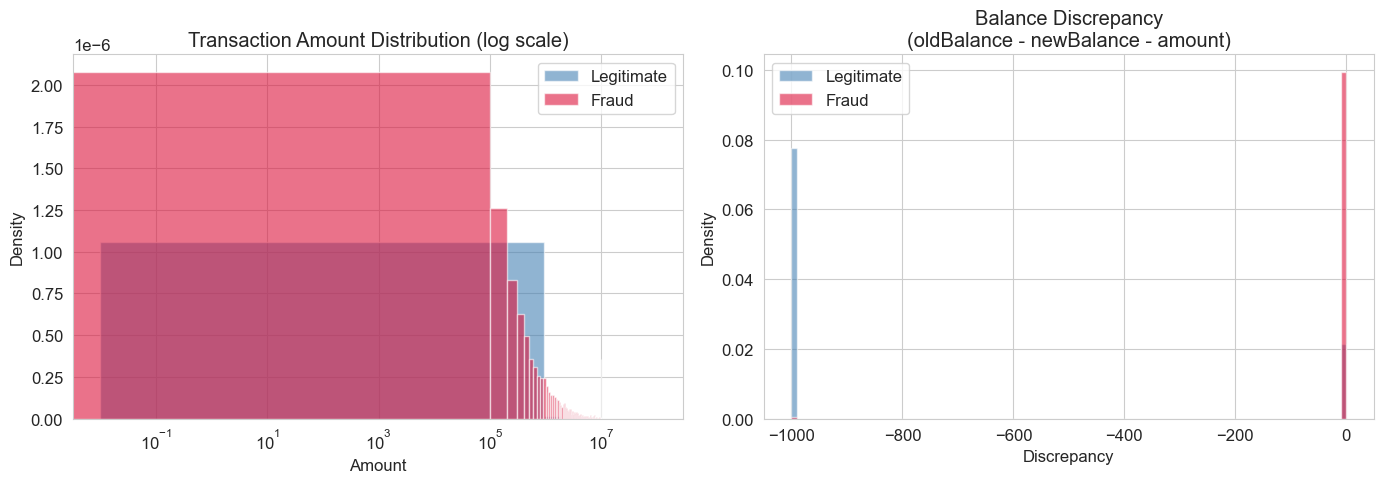

=== Balance Discrepancy Stats ===
Legitimate - mean: -201338.56
Fraud      - mean: -10692.33


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：交易金额分布
axes[0].hist(df[df['isFraud']==0]['amount'],
             bins=100, alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[0].hist(df[df['isFraud']==1]['amount'],
             bins=100, alpha=0.6, color='crimson', label='Fraud', density=True)
axes[0].set_xscale('log')
axes[0].set_title('Transaction Amount Distribution (log scale)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Density')
axes[0].legend()

# 右图：余额变动异常
# 正常情况：newbalanceOrig = oldbalanceOrg - amount
# 欺诈时这个等式可能不成立
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']

axes[1].hist(df[df['isFraud']==0]['balance_diff'].clip(-1000, 1000),
             bins=100, alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[1].hist(df[df['isFraud']==1]['balance_diff'].clip(-1000, 1000),
             bins=100, alpha=0.6, color='crimson', label='Fraud', density=True)
axes[1].set_title('Balance Discrepancy\n(oldBalance - newBalance - amount)')
axes[1].set_xlabel('Discrepancy')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# 数值统计
print("=== Balance Discrepancy Stats ===")
print(f"Legitimate - mean: {df[df['isFraud']==0]['balance_diff'].mean():.2f}")
print(f"Fraud      - mean: {df[df['isFraud']==1]['balance_diff'].mean():.2f}")

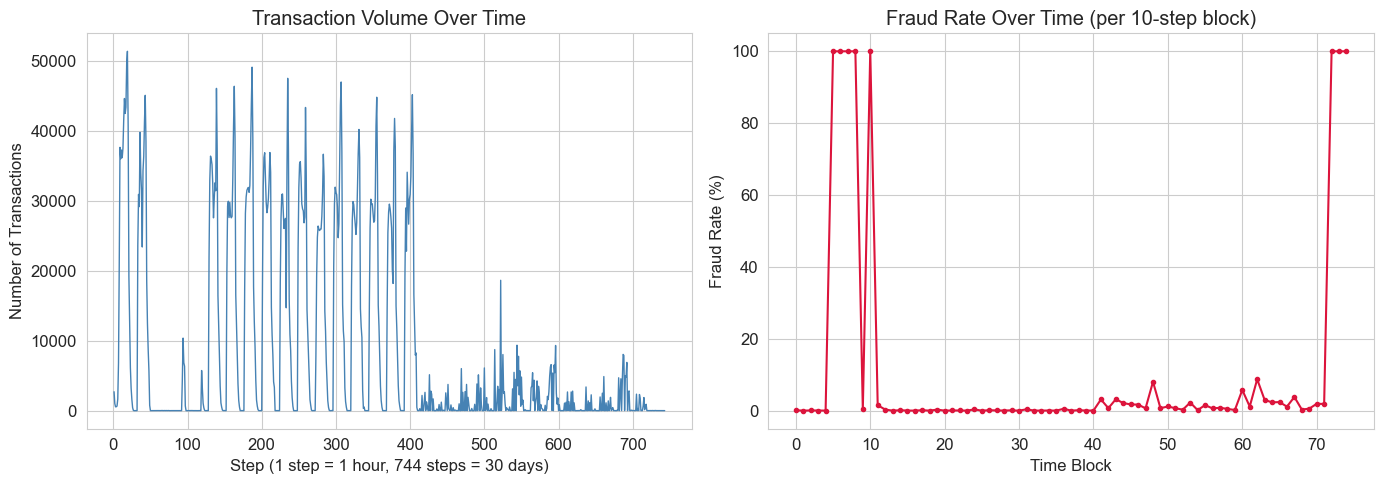

=== Time Range ===
Total steps: 743 (≈ 31 days)
Fraud only in steps: 1 to 743


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：每个 step 的交易量
step_counts = df.groupby('step').size()
axes[0].plot(step_counts.index, step_counts.values, 
             color='steelblue', linewidth=1)
axes[0].set_title('Transaction Volume Over Time')
axes[0].set_xlabel('Step (1 step = 1 hour, 744 steps = 30 days)')
axes[0].set_ylabel('Number of Transactions')

# 右图：欺诈率随时间变化（每10个step一个块）
df['time_block'] = df['step'] // 10
fraud_rate_time = df.groupby('time_block')['isFraud'].mean() * 100
axes[1].plot(fraud_rate_time.index, fraud_rate_time.values,
             color='crimson', linewidth=1.5, marker='o', markersize=3)
axes[1].set_title('Fraud Rate Over Time (per 10-step block)')
axes[1].set_xlabel('Time Block')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

print("=== Time Range ===")
print(f"Total steps: {df['step'].max()} (≈ {df['step'].max()/24:.0f} days)")
print(f"Fraud only in steps: {df[df['isFraud']==1]['step'].min()} to {df[df['isFraud']==1]['step'].max()}")

- 左图： 交易量在 step ~400 之后骤降，说明 PaySim 模拟的后半段数据稀疏很多，这会影响我们的 temporal split 策略。
- 右图： 欺诈率在 step 5-10 和 step 73 附近飙升到 100%，意味着那几个时间窗口内所有交易都是欺诈。这是 PaySim 合成数据的特性，欺诈是集中注入的，不像真实数据那样均匀分布。


这个对我们的 temporal split 有直接影响，如果切分点恰好落在这些集中欺诈区域内，train 或 test 的欺诈率会严重失真。我们需要了解一下这些峰值的具体情况

In [6]:
# 查看欺诈率 100% 的 time block 具体情况
print("=== Time blocks with fraud rate > 50% ===")
block_stats = df.groupby('time_block').agg(
    total=('isFraud', 'count'),
    fraud=('isFraud', 'sum'),
    fraud_rate=('isFraud', 'mean')
).reset_index()
print(block_stats[block_stats['fraud_rate'] > 0.5])

print("\n=== Transaction volume after step 400 ===")
print(f"Steps 1-400:   {len(df[df['step'] <= 400]):,} transactions")
print(f"Steps 401-743: {len(df[df['step'] > 400]):,} transactions")
print(f"Fraud in steps 1-400:   {df[df['step'] <= 400]['isFraud'].sum():,}")
print(f"Fraud in steps 401-743: {df[df['step'] > 400]['isFraud'].sum():,}")

=== Time blocks with fraud rate > 50% ===
    time_block  total  fraud  fraud_rate
5            5    118    118         1.0
6            6    148    148         1.0
7            7    112    112         1.0
8            8    110    110         1.0
10          10    118    118         1.0
72          72    104    104         1.0
73          73    128    128         1.0
74          74     50     50         1.0

=== Transaction volume after step 400 ===
Steps 1-400:   5,787,030 transactions
Steps 401-743: 575,590 transactions
Fraud in steps 1-400:   4,477
Fraud in steps 401-743: 3,736


In [7]:
split_idx = int(len(df) * 0.8)
split_step = df.iloc[split_idx]['step']

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

print("=== PaySim Temporal Split (80/20) ===")
print(f"Split index: {split_idx:,}")
print(f"Split at step: {split_step}")
print()
print(f"Train: {len(train_df):,} rows | steps 1 to {train_df['step'].max()}")
print(f"  Fraud: {train_df['isFraud'].sum():,} ({train_df['isFraud'].mean()*100:.3f}%)")
print()
print(f"Test:  {len(test_df):,} rows | steps {test_df['step'].min()} to {test_df['step'].max()}")
print(f"  Fraud: {test_df['isFraud'].sum():,} ({test_df['isFraud'].mean()*100:.3f}%)")
print()
print("Note: 100% fraud blocks in steps 50-80 fall within train set")
print("Note: 100% fraud blocks in steps 720-749 fall within test set")

=== PaySim Temporal Split (80/20) ===
Split index: 5,090,096
Split at step: 355

Train: 5,090,096 rows | steps 1 to 355
  Fraud: 3,959 (0.078%)

Test:  1,272,524 rows | steps 355 to 743
  Fraud: 4,254 (0.334%)

Note: 100% fraud blocks in steps 50-80 fall within train set
Note: 100% fraud blocks in steps 720-749 fall within test set
